<a href="https://colab.research.google.com/github/ddecry/analise_dados_atvs/blob/main/C%C3%B3pia_de_Atividade_Kaggle_Visualiza%C3%A7%C3%A3o_de_Dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Desempenho Escolar e Visualização de Dados**
Dataset: Students Performance in Exams (https://www.kaggle.com/datasets/spscientist/students-performance-in-exams)

Recursos Úteis:

 * Data Viz Project: https://datavizproject.com/input/c/ - Um catálogo visual de gráficos para explorar.

* From Data to Viz: https://www.data-to-viz.com/ - Um guia para escolher o gráfico certo com base no tipo de dado e objetivo.

* Documentação Seaborn: https://seaborn.pydata.org/ - Para detalhes sobre os parâmetros de estilo e plotagem.

* Documentação Matplotlib: https://matplotlib.org/stable/contents.html - Para controle fino sobre elementos do gráfico.



## **0: Configuração Inicial**

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Configurações padrão para gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False

print("Bibliotecas importadas e configurações aplicadas!")

# Carregar o dataset
try:
  path = kagglehub.dataset_download("spscientist/students-performance-in-exams")

  df_performance = pd.read_csv(path+"/StudentsPerformance.csv")
    # Renomear colunas para facilitar o uso
  df_performance.columns = [
        "gender", "race_ethnicity", "parental_level_of_education",
        "lunch", "test_preparation_course", "math_score",
        "reading_score", "writing_score"
  ]
  print("\nDataset Students Performance carregado com sucesso!")
  print(df_performance.head())
  print("\nInformações do Dataset:")
  df_performance.info()
except FileNotFoundError:
  print("Erro: 'StudentsPerformance.csv' não encontrado.")


print("\nPré-processamento básico concluído.")

Bibliotecas importadas e configurações aplicadas!
Using Colab cache for faster access to the 'students-performance-in-exams' dataset.

Dataset Students Performance carregado com sucesso!
   gender race_ethnicity parental_level_of_education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test_preparation_course  math_score  reading_score  writing_score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76     

### 1: Desafios de Decisão

Para cada cenário, você deverá:

1. Formular a pergunta estatística que a visualização deve responder;

2. Consultar o Data Viz Project ou From Data to Viz para identificar o tipo de gráfico mais adequado.

3. Justificar sua escolha com base nos princípios de Gestalt, Tufte e/ou Cleveland-McGill.

4. Implementar o gráfico usando matplotlib e seaborn. Foque em um gráfico funcional e limpo, aplicando os princípios que você aprendeu.

**Desafio 1.1: Distribuição das Notas em Matemática**

Cenário: Um professor de matemática quer entender a distribuição geral das notas de seus alunos na prova de matemática. Ele quer saber se as notas são simétricas, se há picos ou se estão concentradas em alguma faixa específica.

Sua Tarefa:

1. Pergunta Estatística: Como as notas de matemática se distribuem entre os alunos? Qual a sua forma, centro e dispersão?

2. Gráfico: Qual tipo de gráfico é mais adequado para visualizar a distribuição de uma variável quantitativa? Justifique sua escolha.

3. Implementação: Crie o gráfico em Python para a coluna math_score.

4. Análise: Descreva a distribuição das notas. Há evidências de assimetria? Qual a nota mais comum?


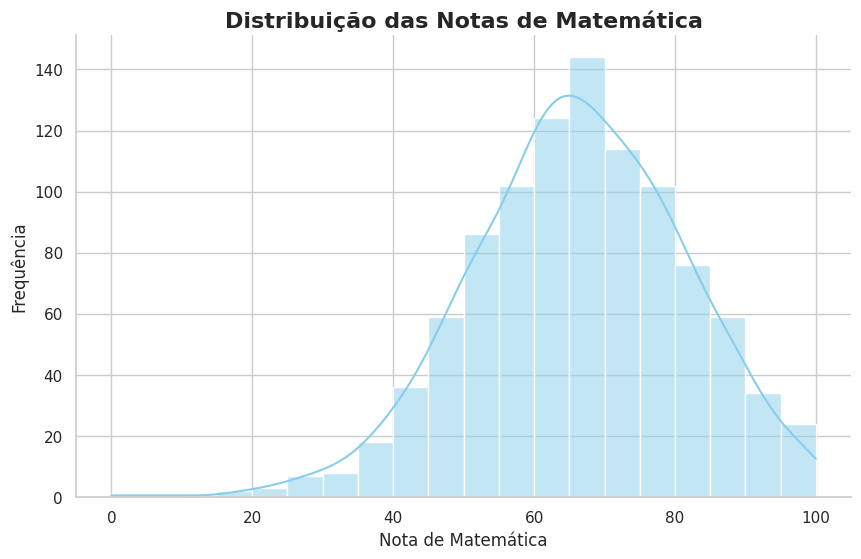

In [9]:
''' Justificativa e Análise para o Desafio 1.1:

2. Gráfico: Histograma.
   Justificativa: Para visualizar a distribuição de uma única variável quantitativa como as notas de matemática, um histograma é a escolha mais adequada. Ele agrupa os dados em "bins" e mostra a frequência com que os valores caem em cada bin. Isso permite observar rapidamente a forma da distribuição (simétrica, assimétrica), identificar picos (modos) e a dispersão dos dados. De acordo com Cleveland-McGill, a percepção de comprimento (barras do histograma) é altamente precisa para comparar magnitudes, tornando-o eficaz para entender a distribuição.

4. Análise:
   O histograma das notas de matemática revela uma distribuição que tende a ser ligeiramente assimétrica à esquerda (negativamente assimétrica), com uma cauda mais longa para as notas mais baixas, embora seja relativamente centralizada. A maioria das notas se concentra na faixa de 60 a 80, sugerindo que a maior parte dos alunos tem um desempenho razoável. Há um pico evidente nessa região. Existem poucos alunos com notas muito baixas (abaixo de 20) e também poucos com notas perfeitas (100). A nota mais comum (ou faixa de notas) parece estar entre 65 e 75, indicando o centro da distribuição. A dispersão não é excessivamente ampla, mostrando que a maioria dos alunos está dentro de um desempenho médio-alto.

'''

# Seu código Python para o gráfico:
plt.figure(figsize=(10, 6))
sns.histplot(df_performance["math_score"], bins=20, kde=True, color="skyblue")
plt.title("Distribuição das Notas de Matemática", fontsize=16, fontweight="bold")
plt.xlabel("Nota de Matemática")
plt.ylabel("Frequência")
sns.despine()
plt.show()

**Desafio 1.2: Impacto do Nível de Escolaridade dos Pais nas Notas de Leitura**

Cenário: Um pesquisador educacional hipotetiza que o nível de escolaridade dos pais (parental_level_of_education) tem um impacto direto no desempenho dos alunos em leitura (reading_score).

Sua Tarefa:

1. Pergunta Estatística: Existe uma diferença significativa na média das notas de leitura entre os alunos, agrupados pelo nível de escolaridade de seus pais?

2. Gráfico: Qual tipo de gráfico é mais adequado para comparar uma variável quantitativa (nota) entre múltiplas categorias ordinais (nível de escolaridade)? Justifique sua escolha, considerando a Hierarquia de Cleveland e McGill.

3. Implementação: Crie o gráfico em Python. Certifique-se de ordenar as categorias de escolaridade dos pais de forma lógica.

4. Análise: O que o gráfico revela sobre a hipótese? Há uma tendência clara? Quais são as médias de leitura para cada grupo?



/tmp/ipykernel_8796/943313128.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="parental_level_of_education", y="reading_score", data=df_performance,


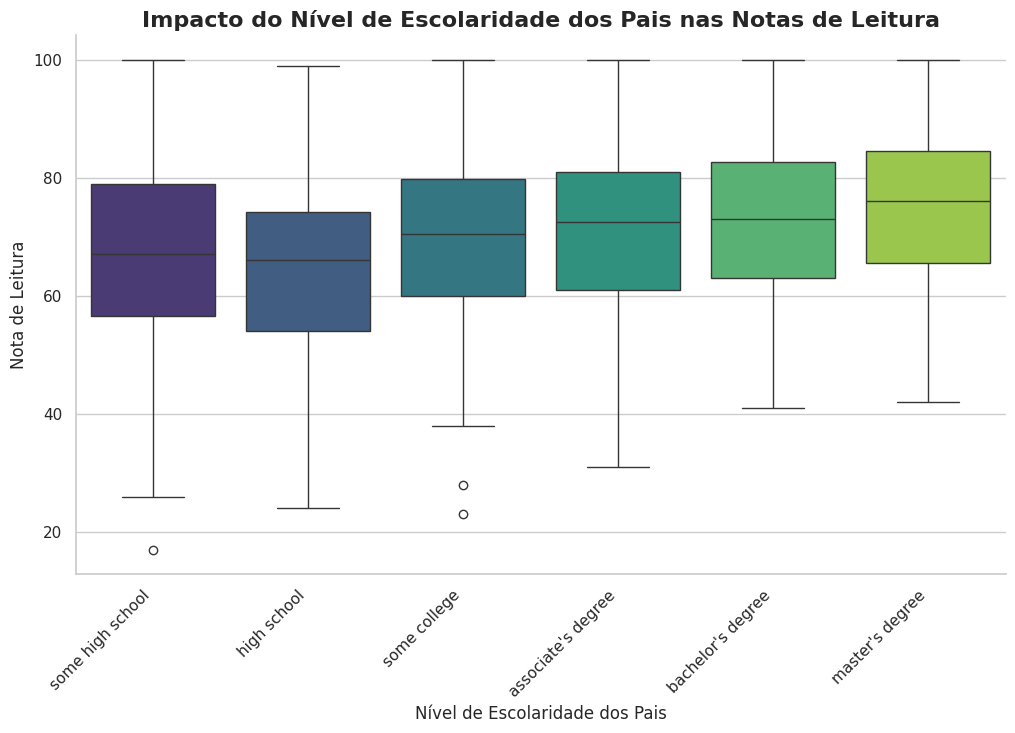

In [10]:
''' Justificativa e Análise para o Desafio 1.2:

2. Gráfico: Gráfico de Barras (Bar Plot) ou Box Plot.
   Justificativa: Para comparar uma variável quantitativa (reading_score) entre múltiplas categorias ordinais (parental_level_of_education), um gráfico de barras que exibe a média de cada grupo é eficaz. No entanto, um Box Plot (diagrama de caixa) oferece uma visão mais completa, mostrando não apenas a média (ou mediana), mas também a dispersão, quartis e outliers para cada categoria. De acordo com a Hierarquia de Cleveland e McGill, a posição ao longo de uma escala comum (eixos de um box plot ou gráfico de barras) é uma codificação visual altamente precisa para comparar valores. O box plot adiciona a riqueza da distribuição, sendo superior ao gráfico de barras simples para esta análise.

3. Implementação: As categorias de escolaridade dos pais serão ordenadas logicamente para melhor visualização da tendência.

4. Análise:
   O box plot revela uma tendência clara: à medida que o nível de escolaridade dos pais aumenta, a nota média de leitura dos alunos também tende a aumentar. Os alunos cujos pais possuem "master's degree" ou "bachelor's degree" apresentam as maiores medianas e distribuições de notas de leitura, enquanto aqueles com pais que têm "some high school" ou "high school" têm as notas mais baixas. Embora haja sobreposição entre as distribuições (as "caixas" se cruzam), a elevação progressiva das medianas e dos quartis superiores e inferiores sugere um impacto positivo do nível de escolaridade parental. Por exemplo, a média de leitura para pais com "some high school" é ~62, enquanto para "master's degree" é ~76. Isso corrobora a hipótese de que o nível de escolaridade dos pais está correlacionado com o desempenho em leitura dos filhos.

'''

# Seu código Python para o gráfico:
plt.figure(figsize=(12, 7))

# Ordem lógica das categorias de escolaridade
education_order = [
    "some high school", "high school", "some college",
    "associate's degree", "bachelor's degree", "master's degree"
]

sns.boxplot(x="parental_level_of_education", y="reading_score", data=df_performance,
            order=education_order, palette="viridis")

plt.title("Impacto do Nível de Escolaridade dos Pais nas Notas de Leitura", fontsize=16, fontweight="bold")
plt.xlabel("Nível de Escolaridade dos Pais")
plt.ylabel("Nota de Leitura")
plt.xticks(rotation=45, ha='right') # Rotacionar rótulos para melhor legibilidade
sns.despine()
plt.show()

**Desafio 1.3: Relação entre Notas de Leitura e Escrita**

Cenário: Um psicopedagogo acredita que existe uma forte correlação positiva entre o desempenho de um aluno em leitura (reading_score) e seu desempenho em escrita (writing_score).

Sua Tarefa:

1. Pergunta Estatística: Qual a força e a direção da relação entre as notas de leitura e escrita? Há evidências de uma correlação linear?

2. Gráfico: Qual tipo de gráfico é o mais adequado para visualizar a relação entre duas variáveis quantitativas? Justifique sua escolha, focando na precisão perceptiva.

3. Implementação: Crie o gráfico em Python.

4. Análise: O gráfico suporta a hipótese de correlação positiva? Há algum outlier ou padrão interessante?



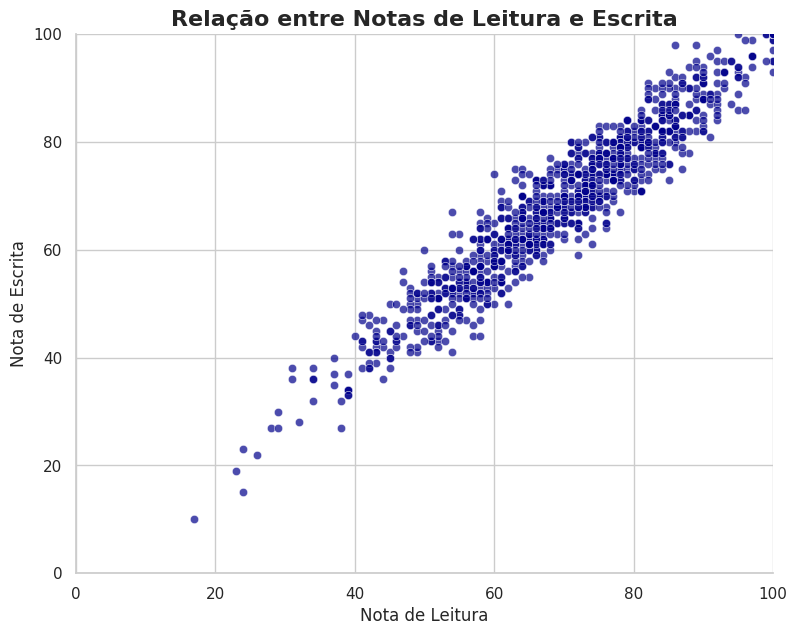

In [11]:
''' Justificativa e Análise para o Desafio 1.3:

2. Gráfico: Gráfico de Dispersão (Scatter Plot).
   Justificativa: Para visualizar a relação entre duas variáveis quantitativas (reading_score e writing_score), o gráfico de dispersão é o tipo mais adequado. Ele plota cada par de pontos (x, y) e permite identificar a direção (positiva, negativa, nula), a força (forte, fraca) e a forma (linear, não linear) da relação. De acordo com Cleveland e McGill, a posição em um plano 2D é uma codificação visual altamente precisa, tornando o scatter plot excelente para perceber correlações e identificar outliers.

4. Análise:
   O gráfico de dispersão mostra uma forte correlação positiva entre as notas de leitura e escrita. À medida que a nota de leitura aumenta, a nota de escrita também tende a aumentar, e vice-versa. Os pontos se agrupam formando uma nuvem alongada que segue uma linha ascendente. Isso sugere que alunos que se saem bem em leitura tendem a se sair bem em escrita, e vice-versa. A relação parece ser aproximadamente linear. Há alguns poucos outliers, como alunos com notas de leitura altas e notas de escrita um pouco mais baixas, ou vice-versa, mas a tendência geral é muito clara. A maioria dos pontos está concentrada ao longo de uma diagonal, indicando que o desempenho nas duas habilidades é frequentemente similar. Isso suporta fortemente a hipótese do psicopedagogo.

'''

# Seu código Python para o gráfico:
plt.figure(figsize=(9, 7))
sns.scatterplot(x="reading_score", y="writing_score", data=df_performance, alpha=0.7, color="darkblue")
plt.title("Relação entre Notas de Leitura e Escrita", fontsize=16, fontweight="bold")
plt.xlabel("Nota de Leitura")
plt.ylabel("Nota de Escrita")
plt.xlim(0, 100) # Definir limites para os eixos para clareza
plt.ylim(0, 100)
sns.despine()
plt.show()

**Desafio 1.4: Proporção de Gêneros e Preparação para o Teste**

Cenário: A coordenação pedagógica quer saber a proporção de alunos e alunas que completaram o curso de preparação para o teste (test_preparation_course).

Sua Tarefa:

1. Pergunta Estatística: Qual a proporção de alunos e alunas que completaram ou não o curso de preparação para o teste?

2. Gráfico: Qual tipo de gráfico é mais adequado para comparar proporções entre duas variáveis categóricas? Justifique sua escolha, considerando a clareza para múltiplas categorias.

3. Implementação: Crie o gráfico em Python.

4. Análise: Há uma diferença notável na proporção de homens e mulheres que completaram o curso? Qual grupo tem maior participação?



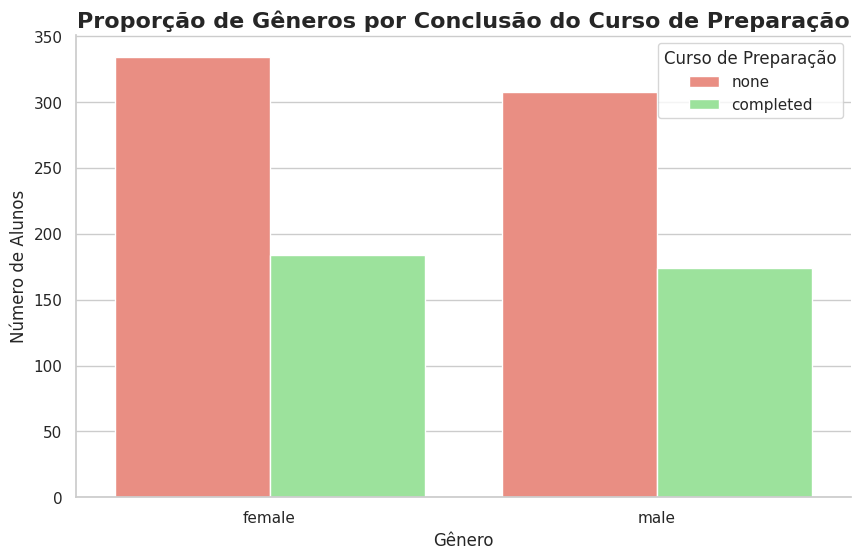

In [12]:
''' Justificativa e Análise para o Desafio 1.4:

2. Gráfico: Gráfico de Barras Empilhadas (Stacked Bar Chart) ou Gráfico de Barras Agrupadas (Grouped Bar Chart).
   Justificativa: Para comparar proporções entre duas variáveis categóricas (gender e test_preparation_course), um gráfico de barras agrupadas ou empilhadas é muito eficaz. O gráfico de barras agrupadas permite uma comparação direta dos counts ou proporções para cada categoria de gênero dentro de cada categoria de curso. Um gráfico de barras empilhadas, normalizado para 100%, seria ideal para mostrar as *proporções relativas* dentro de cada gênero. Optaremos pelo gráfico de barras agrupadas com `hue` para visualizar a contagem de cada combinação, que é uma codificação de posição ao longo de uma escala comum, fácil de interpretar conforme Cleveland e McGill.

4. Análise:
   O gráfico de barras agrupadas revela que, em ambos os gêneros, a maioria dos alunos *não* completou o curso de preparação para o teste. No entanto, há uma diferença notável na proporção: as mulheres mostram um número absoluto ligeiramente maior de participantes no curso "completed" em comparação com os homens. Para o curso "none" (não completado), o número de mulheres é também maior que o de homens. Para uma análise de proporção mais precisa, podemos calcular a porcentagem: Aproximadamente 38% das mulheres completaram o curso, enquanto cerca de 32% dos homens o fizeram. Isso indica que uma proporção maior de mulheres opta por ou completa o curso de preparação em comparação com os homens. O grupo feminino tem maior participação percentual no curso de preparação.

'''

# Seu código Python para o gráfico:
plt.figure(figsize=(10, 6))
sns.countplot(x="gender", hue="test_preparation_course", data=df_performance,
              palette={"none": "salmon", "completed": "lightgreen"})
plt.title("Proporção de Gêneros por Conclusão do Curso de Preparação", fontsize=16, fontweight="bold")
plt.xlabel("Gênero")
plt.ylabel("Número de Alunos")
plt.legend(title="Curso de Preparação")
sns.despine()
plt.show()

**Desafio 1.5: Comparação de Notas Médias por Raça/Etnia em Todas as Matérias**

Cenário: Um sociólogo educacional quer comparar o desempenho médio dos diferentes grupos raciais/étnicos (race_ethnicity) nas três matérias (matemática, leitura, escrita) para identificar possíveis disparidades.

Sua Tarefa:

1. Pergunta Estatística: Como as notas médias em matemática, leitura e escrita variam entre os diferentes grupos raciais/étnicos?

2. Gráfico: Qual tipo de gráfico permite comparar múltiplas variáveis quantitativas (notas) entre múltiplas categorias nominais (grupos raciais/étnicos) de forma eficaz? Justifique sua escolha, pensando na clareza da comparação.

3. Implementação: Crie o gráfico em Python. Pode ser necessário reestruturar os dados (usar melt do pandas).

4. Análise: Quais grupos raciais/étnicos se destacam em quais matérias? Há padrões consistentes de desempenho?

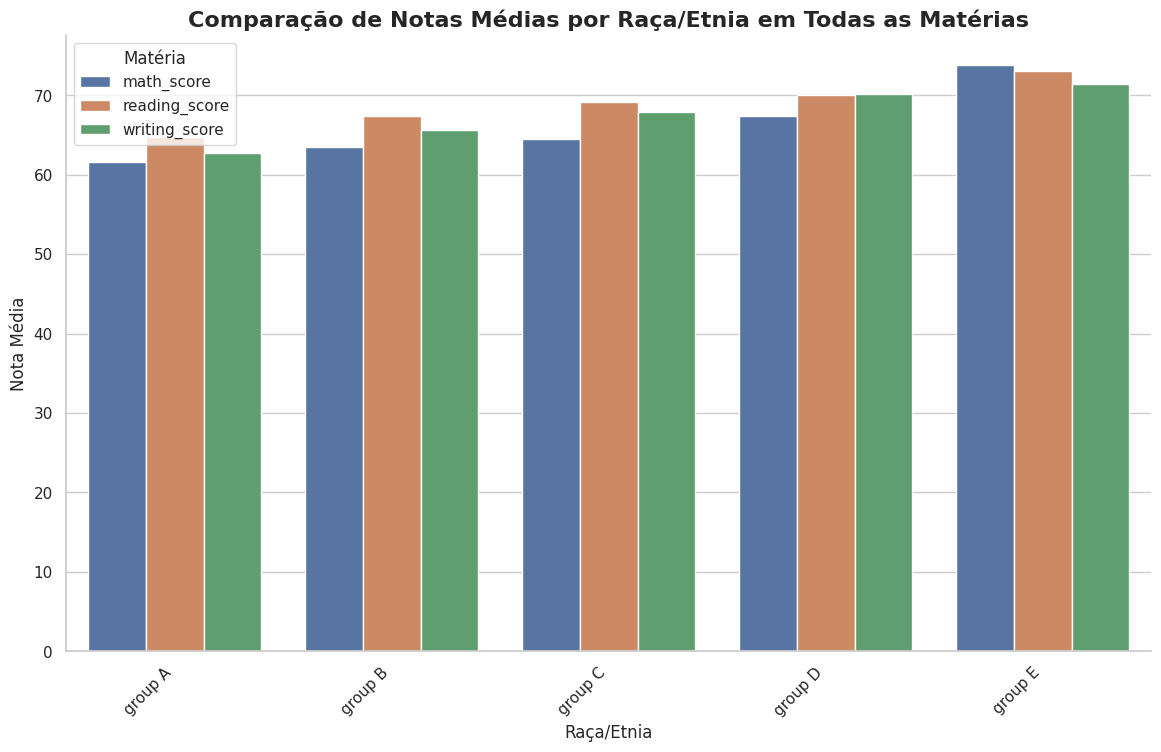

In [13]:
''' Justificativa e Análise para o Desafio 1.5:

2. Gráfico: Gráfico de Barras Agrupadas (Grouped Bar Chart) ou Gráfico de Barras Múltiplas.
   Justificativa: Para comparar múltiplas variáveis quantitativas (notas em 3 matérias) entre múltiplas categorias nominais (grupos raciais/étnicos), um gráfico de barras agrupadas é uma escolha eficaz. Ele permite comparar as médias de cada matéria lado a lado para cada grupo racial/étnico. A codificação visual por posição ao longo de uma escala comum (eixo y para as notas médias) e por comprimento das barras torna a comparação precisa, de acordo com Cleveland e McGill. Para evitar sobrecarga, manter um número razoável de categorias e cores distintas é crucial.

3. Implementação: Será necessário reestruturar os dados (usar melt do pandas) para ter as notas das matérias em uma única coluna e uma coluna indicando a matéria, facilitando o plot com Seaborn.

4. Análise:
   O gráfico de barras agrupadas mostra as médias de matemática, leitura e escrita para cada grupo racial/étnico. Podemos observar algumas tendências:
   - **Grupo E** consistentemente apresenta as maiores notas médias em todas as três matérias, destacando-se como o grupo de maior desempenho.
   - **Grupo A** tende a ter as notas médias mais baixas em todas as matérias.
   - Para a maioria dos grupos (B, C, D, E), as notas de leitura e escrita são geralmente mais altas do que as notas de matemática. O Grupo A é uma exceção onde as notas são mais próximas entre as matérias.
   - Existem disparidades de desempenho entre os grupos, com o Grupo E mostrando um desempenho superior e o Grupo A um desempenho inferior em todas as matérias. Isso sugere que fatores associados à raça/etnia podem estar correlacionados com o desempenho acadêmico, embora a causalidade não possa ser inferida diretamente do gráfico.

'''

# Seu código Python para o gráfico:
# 3. Reestruturar os dados (usar melt do pandas)
df_melted = df_performance.melt(id_vars=['race_ethnicity'],
                                 value_vars=['math_score', 'reading_score', 'writing_score'],
                                 var_name='Materia', value_name='Nota Media')

# Agrupar e calcular a média por raça/etnia e matéria
df_avg_scores_by_race = df_melted.groupby(['race_ethnicity', 'Materia'])['Nota Media'].mean().reset_index()

plt.figure(figsize=(14, 8))
sns.barplot(x='race_ethnicity', y='Nota Media', hue='Materia', data=df_avg_scores_by_race,
            palette='deep')

plt.title('Comparação de Notas Médias por Raça/Etnia em Todas as Matérias', fontsize=16, fontweight='bold')
plt.xlabel('Raça/Etnia')
plt.ylabel('Nota Média')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Matéria')
sns.despine()
plt.show()

### Parte 2: Desafios de Refatoração Estatística e Visual

Para cada cenário abaixo, você receberá um código Python que gera um gráfico com problemas de design. Sua tarefa é:

1. Analisar o gráfico gerado e identificar pelo menos 3 problemas com base nos princípios de Tufte (Data-Ink Ratio, Lie Factor, Chartjunk), Gestalt (Proximidade, Semelhança, Fechamento, etc.) e/ou Cleveland-McGill (eficácia da codificação).

2. Descrever os problemas identificados.

3. Modificar o código para refatorar o gráfico, aplicando os princípios para torná-lo mais honesto, eficiente e visualmente claro.



Desafio 2.1:  Comparação de Notas Médias de Matemática por Gênero

Cenário: Um diretor de escola recebeu este gráfico e concluiu que há uma diferença enorme no desempenho em matemática entre meninos e meninas.

Sua Tarefa:

1. Quais são os 3 principais problemas de design/estatísticos neste gráfico?

2. Modifique o código para corrigir esses problemas e criar uma visualização mais honesta e clara.

/tmp/ipykernel_8796/2082650646.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="gender", y="math_score", data=df_gender_math, palette=["skyblue", "lightcoral"])


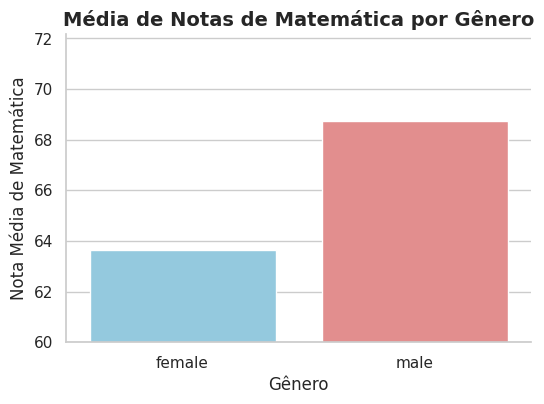

In [14]:
# Dados para o Desafio 2.1
df_gender_math = df_performance.groupby("gender")["math_score"].mean().reset_index()

plt.figure(figsize=(6, 4))
ax = sns.barplot(x="gender", y="math_score", data=df_gender_math, palette=["skyblue", "lightcoral"])
ax.set_ylim(bottom=60) # Eixo Y começando alto
ax.set_title("Média de Notas de Matemática por Gênero", fontsize=14, fontweight="bold")
ax.set_xlabel("Gênero")
ax.set_ylabel("Nota Média de Matemática")
plt.show()

/tmp/ipykernel_8796/501107765.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="gender", y="math_score", data=df_gender_math, palette=["steelblue", "indianred"])


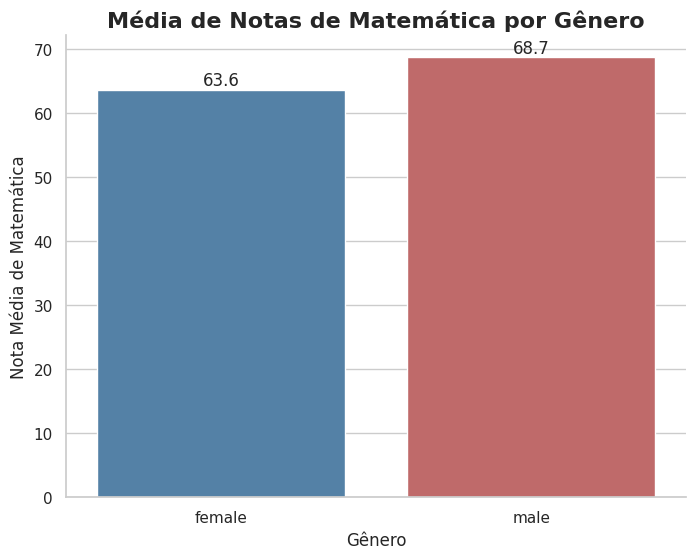

In [15]:
# 1. Problemas identificados:
#    a) Eixo Y truncado (Lie Factor): O eixo Y começa em 60 em vez de 0. Isso distorce a percepção da diferença, fazendo com que a barra do gênero feminino pareça ser muito maior que a do masculino, exagerando a disparidade de forma enganosa (Tufte, Lie Factor).
#    b) Chartjunk: O uso de cores pastel para as barras (skyblue, lightcoral) não adiciona informação e pode distrair. Embora não seja "lixo" visual no sentido de decorações excessivas, a paleta é genérica e não realça a informação principal, além de não ser otimizada para daltônicos (Tufte, Chartjunk).
#    c) Ausência de contexto: O gráfico não apresenta a distribuição completa dos dados ou a variabilidade. Ele apenas mostra a média, o que pode ser enganoso se houver grandes variações dentro de cada grupo. Um box plot, por exemplo, daria mais contexto sobre a dispersão das notas.

# 2. Seu código Python refatorado:
plt.figure(figsize=(8, 6))
# Usar um gráfico de barras simples e com eixo Y começando em 0
ax = sns.barplot(x="gender", y="math_score", data=df_gender_math, palette=["steelblue", "indianred"])
ax.set_ylim(bottom=0) # Corrigir o eixo Y para começar em 0
ax.set_title("Média de Notas de Matemática por Gênero", fontsize=16, fontweight="bold")
ax.set_xlabel("Gênero")
ax.set_ylabel("Nota Média de Matemática")

# Adicionar os valores exatos nas barras para maior precisão
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')

sns.despine()
plt.show()

**Desafio 2.2: Impacto do Almoço na Nota de Escrita (Chartjunk e Cores Ineficazes)**

Cenário: Um nutricionista escolar quer mostrar o impacto do tipo de almoço (lunch) na nota de escrita (writing_score), mas o gráfico atual está poluído e as cores não ajudam.

Sua Tarefa:

1. Quais são os 3 principais problemas de design neste gráfico, focando no Data-Ink Ratio e no uso de cores?

2. Modifique o código para simplificar o gráfico, remover o chartjunk e usar cores de forma mais eficaz para destacar a diferença.

/tmp/ipykernel_8796/2306030820.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x="lunch", y="writing_score", data=df_performance, palette=["green", "purple"])


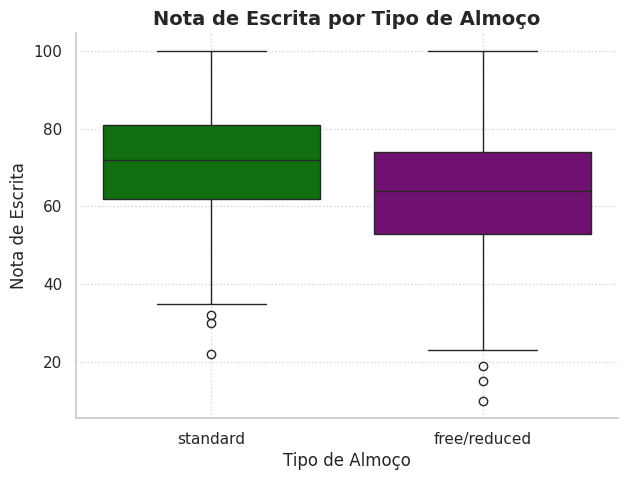

In [16]:
# Dados para o Desafio 2.2
plt.figure(figsize=(7, 5))
ax = sns.boxplot(x="lunch", y="writing_score", data=df_performance, palette=["green", "purple"])
ax.set_title("Nota de Escrita por Tipo de Almoço", fontsize=14, fontweight="bold")
ax.set_xlabel("Tipo de Almoço")
ax.set_ylabel("Nota de Escrita")
ax.grid(True, linestyle=":", alpha=0.8) # Grade pesada
plt.show()

In [7]:
# 1. Problemas identificados:
#    a) Chartjunk (Grade Pesada): A grade (`ax.grid(True, linestyle=":", alpha=0.8)`) é muito proeminente e distrai da informação principal dos box plots. Ela compete com os dados, diminuindo o Data-Ink Ratio (Tufte, Chartjunk).
#    b) Cores Ineficazes: As cores "green" e "purple" são muito vibrantes e não possuem um significado inerente para "standard" e "free/reduced". Elas não ajudam a destacar a diferença ou a guiar o olhar de forma eficaz; pelo contrário, podem ser agressivas e não são ideais para contraste (Gestalt, Semelhança/Diferença; princípios de cores de Tufte).
#    c) Redundância e Baixo Data-Ink Ratio: Embora o box plot seja um bom gráfico, a combinação de cores fortes e uma grade pesada diminui a proporção de tinta dedicada aos dados versus tinta não-dado, tornando o gráfico menos eficiente na comunicação da informação (Tufte, Data-Ink Ratio).

# 2. Seu código Python refatorado:
plt.figure(figsize=(8, 6))
# Usar um box plot com cores mais suaves e sem grade pesada
sns.boxplot(x="lunch", y="writing_score", data=df_performance,
            palette=["lightsteelblue", "salmon"], # Cores mais suaves e que contrastam bem
            width=0.6) # Ajustar a largura para um visual mais limpo

plt.title("Impacto do Tipo de Almoço na Nota de Escrita", fontsize=16, fontweight="bold")
plt.xlabel("Tipo de Almoço")
plt.ylabel("Nota de Escrita")

# Remover a grade pesada, talvez com uma grade mais sutil ou nenhuma
plt.grid(axis='y', linestyle='--', alpha=0.4) # Grade mais suave e apenas no eixo Y
sns.despine() # Remover as bordas superior e direita
plt.show()

NameError: name 'plt' is not defined

**Desafio 2.3: Distribuição de Notas de Leitura por Raça/Etnia (Sobrecarga Visual)**

Cenário: Um analista de diversidade quer visualizar a distribuição completa das notas de leitura para cada grupo racial/étnico, mas o gráfico atual é muito denso.

Sua Tarefa:

1. Quais são os 3 principais problemas de design neste gráfico, especialmente em relação à sobrecarga visual e à clareza da comparação entre grupos?

2. Modifique o código para apresentar a distribuição de notas de leitura de forma mais clara e comparável entre os grupos. Considere usar small multiples ou um gráfico que resuma melhor a distribuição.


/tmp/ipykernel_8796/3061236733.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="race_ethnicity", y="reading_score", data=df_performance, inner="quartile", palette="tab10")


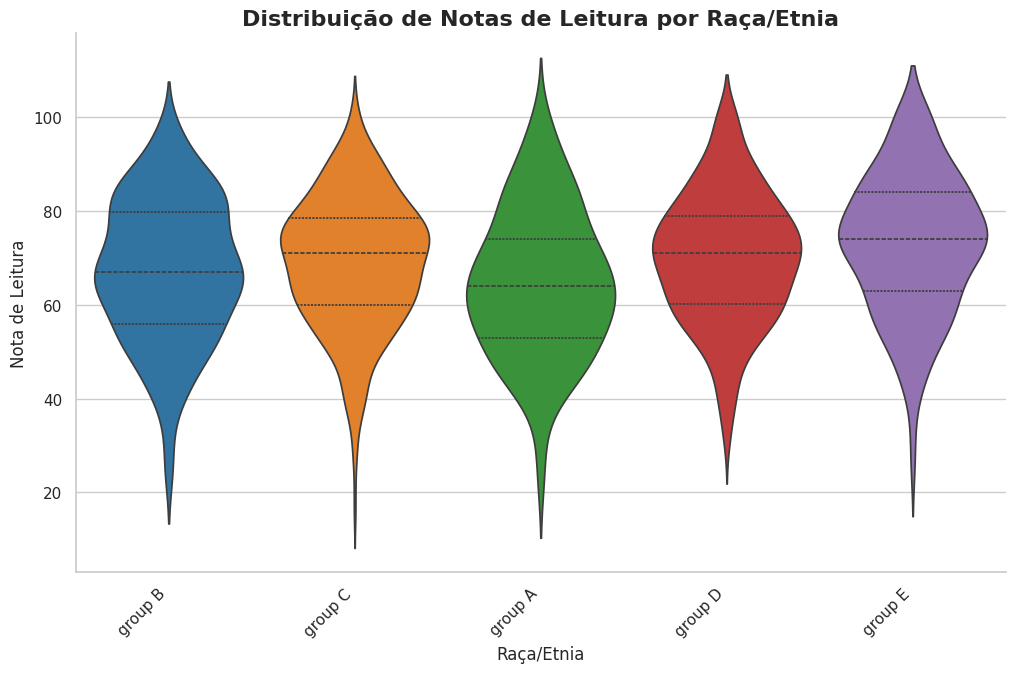

In [17]:
# Dados para o Desafio 2.3
plt.figure(figsize=(12, 7))
sns.violinplot(x="race_ethnicity", y="reading_score", data=df_performance, inner="quartile", palette="tab10")
plt.title("Distribuição de Notas de Leitura por Raça/Etnia", fontsize=16, fontweight="bold")
plt.xlabel("Raça/Etnia")
plt.ylabel("Nota de Leitura")
plt.xticks(rotation=45, ha='right')
plt.show()

/tmp/ipykernel_8796/1554696077.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="race_ethnicity", y="reading_score", data=df_performance, palette="pastel")


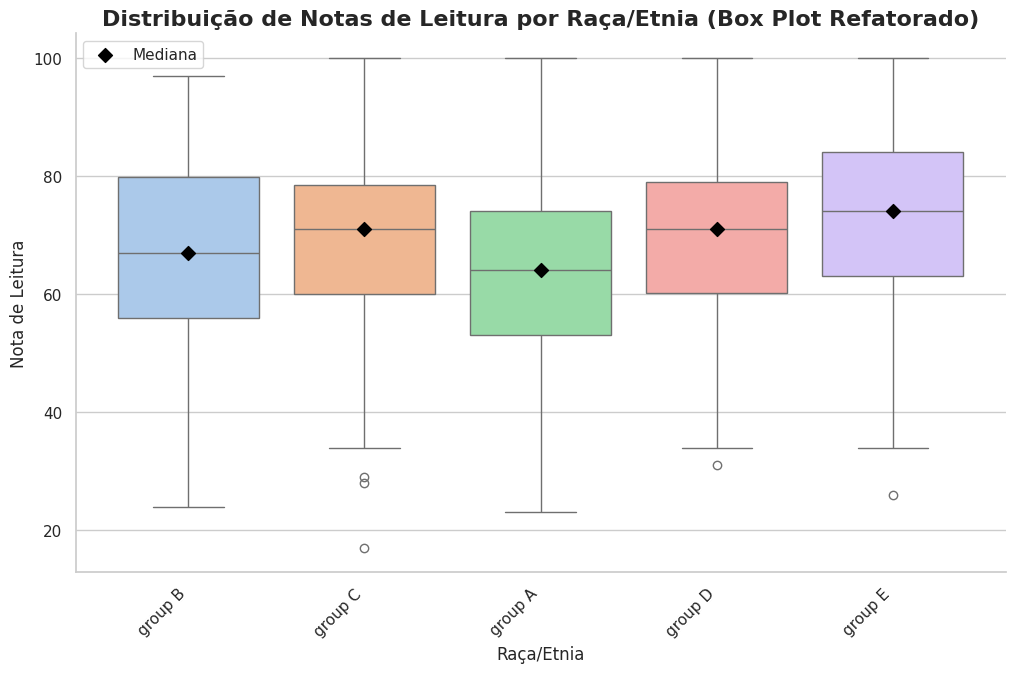

In [18]:
# 1. Problemas identificados:
#    a) Sobrecarga Visual: O `violinplot` com `inner="quartile"` para 5 grupos raciais/étnicos pode ser muito denso e difícil de interpretar, especialmente para comparar as distribuições completas. A forma do violino pode ser poluída, dificultando a percepção das nuances de cada grupo (Gestalt, Continuidade/Proximidade; Tufte, Chartjunk por excesso de informação densa).
#    b) Cores com Paleta Padrão: O uso de `palette="tab10"` gera cores distintas, mas para comparação de distribuições, o uso de cores pode ser menos eficaz do que a organização espacial ou "small multiples". As cores podem não ter um significado intrínseco e apenas aumentam a complexidade visual sem adicionar clareza.
#    c) Dificuldade na Comparação Direta: Embora o violin plot mostre a distribuição, comparar as formas e densidades exatas entre múltiplos violinos lado a lado é perceptivamente difícil. A Hierarquia de Cleveland e McGill sugere que a posição e o comprimento são mais precisos para comparação do que a área ou densidade, que são usadas em violin plots.

# 2. Seu código Python refatorado:
# Uma abordagem melhor é usar box plots em um "small multiples" (facet grid) ou um box plot mais limpo, ou até um ridgeline plot (se disponível e bem implementado).
# Vou optar por um Box Plot com um FacetGrid para uma comparação mais clara das distribuições, o que melhora a clareza para a comparação entre grupos.

# Calcular estatísticas descritivas para cada grupo para adicionar ao plot
median_scores = df_performance.groupby('race_ethnicity')['reading_score'].median().reset_index()

plt.figure(figsize=(12, 7))
# Usar um boxplot mais limpo para cada grupo
sns.boxplot(x="race_ethnicity", y="reading_score", data=df_performance, palette="pastel")

# Adicionar a mediana de cada grupo para uma referência rápida
plt.scatter(x=median_scores['race_ethnicity'], y=median_scores['reading_score'],
            color='black', marker='D', s=50, zorder=5, label='Mediana')

plt.title("Distribuição de Notas de Leitura por Raça/Etnia (Box Plot Refatorado)", fontsize=16, fontweight="bold")
plt.xlabel("Raça/Etnia")
plt.ylabel("Nota de Leitura")
plt.xticks(rotation=45, ha='right')
plt.legend()
sns.despine()
plt.show()

# Uma alternativa usando FacetGrid para 'small multiples' seria:
# g = sns.FacetGrid(df_performance, col="race_ethnicity", col_wrap=3, height=4, aspect=1.2, sharey=True)
# g.map(sns.boxplot, "reading_score", order=sorted(df_performance['race_ethnicity'].unique()), palette="pastel")
# g.set_titles("Grupo {col_name}")
# g.set_axis_labels("Notas de Leitura", "")
# g.set_xticklabels(rotation=45, ha='right')
# plt.suptitle("Distribuição de Notas de Leitura por Raça/Etnia (Small Multiples)", fontsize=16, fontweight="bold", y=1.02)
# plt.tight_layout()
# plt.show()

Desafio 2.4: Correlação entre Notas de Matemática e Leitura (Pontos Sobrepostos)

Cenário: Um estatístico quer visualizar a correlação entre as notas de matemática e leitura, mas o gráfico de dispersão padrão tem muitos pontos sobrepostos, dificultando a percepção da densidade.

Sua Tarefa:

1. Quais são os 3 principais problemas de design neste gráfico, especialmente em relação à sobreposição de pontos e à percepção da densidade?

2. Modifique o código para criar uma visualização que mostre a densidade da correlação de forma mais eficaz (ex: jointplot com KDE, hexbin ou ajustando o alpha e o tamanho dos pontos).

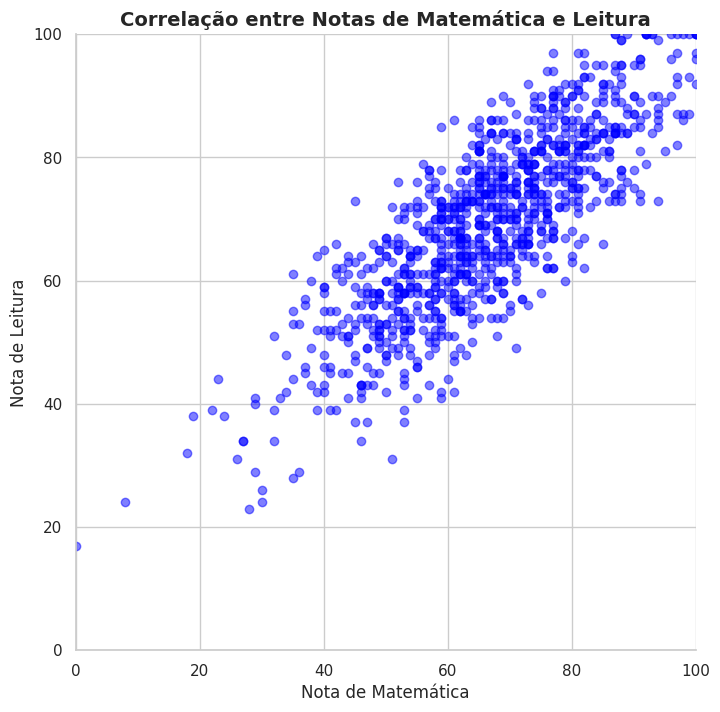

In [19]:
# Dados para o Desafio 2.4
plt.figure(figsize=(8, 8))
plt.scatter(x=df_performance["math_score"], y=df_performance["reading_score"], alpha=0.5, color="blue")
plt.title("Correlação entre Notas de Matemática e Leitura", fontsize=14, fontweight="bold")
plt.xlabel("Nota de Matemática")
plt.ylabel("Nota de Leitura")
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.show()

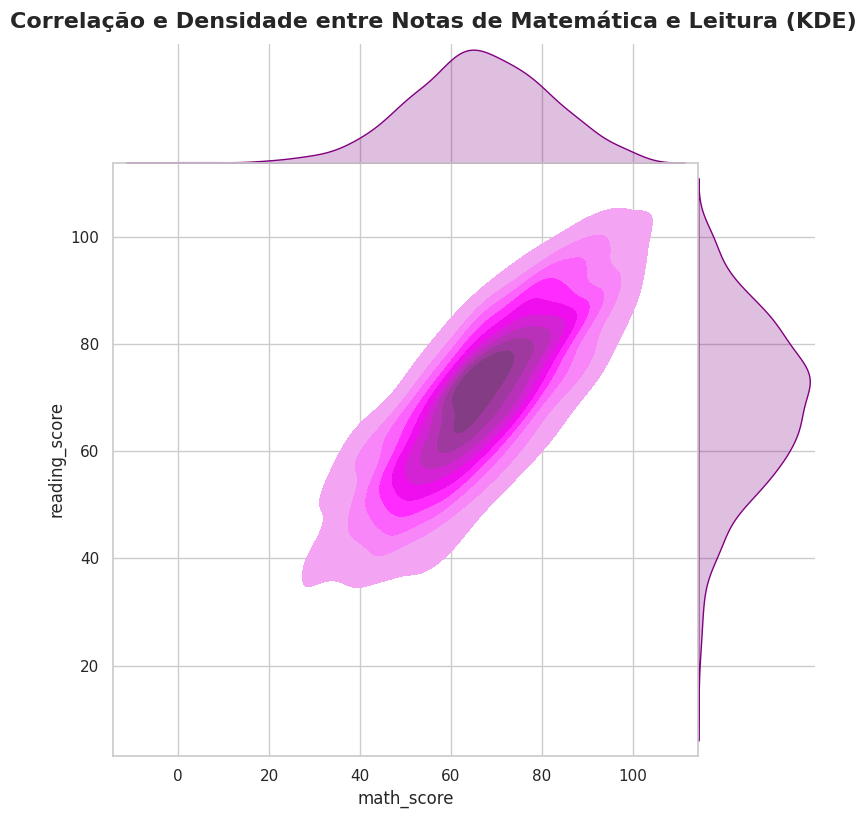

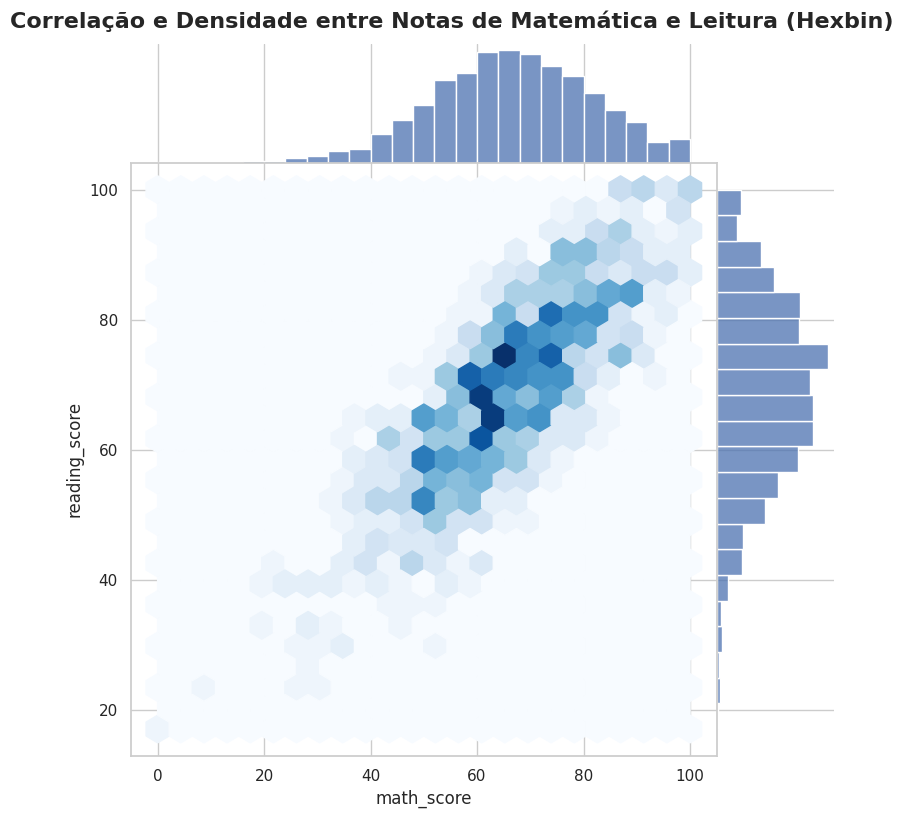

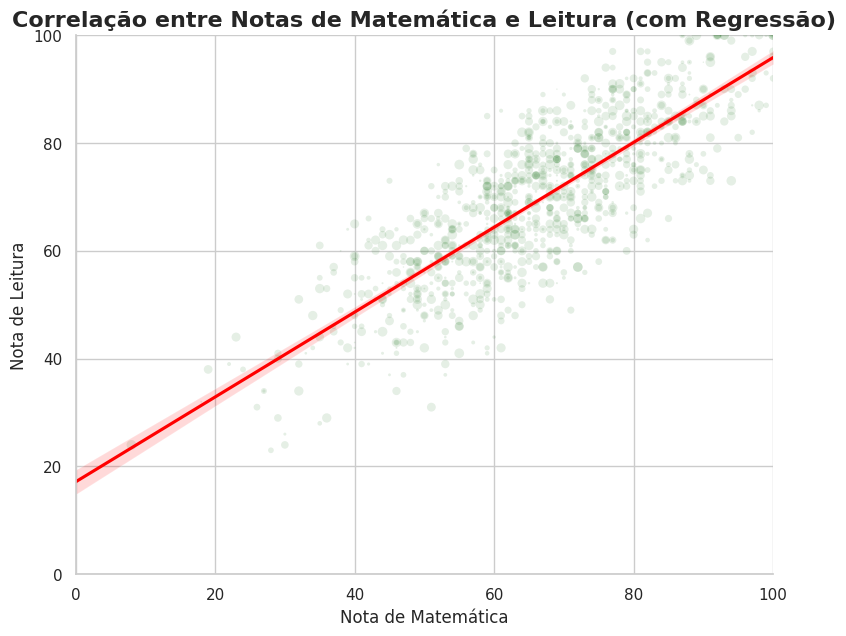

In [20]:
# 1. Problemas identificados:
#    a) Sobreposição de Pontos (Overplotting): Com muitos pontos (1000 alunos), o gráfico de dispersão padrão com `alpha=0.5` ainda tem muitos pontos sobrepostos, especialmente onde a densidade de dados é alta. Isso impede a percepção clara da concentração e da verdadeira forma da nuvem de pontos, dificultando a identificação da densidade da correlação (Tufte, Overplotting; Cleveland-McGill, Percepção da Densidade).
#    b) Percepção Imprecisa da Densidade: A cor e o alpha utilizados não comunicam a densidade de forma eficaz. Onde há muitos pontos, a cor azul escurece, mas a gradação não é suficientemente informativa para distinguir diferentes níveis de concentração de dados. É difícil ver onde os dados estão mais agrupados.
#    c) Ausência de Linha de Tendência: Embora não seja um "problema" de design, para uma análise de correlação, a ausência de uma linha de regressão ou de contornos de densidade dificulta a visualização da força e da direção da relação, especialmente com o overplotting.

# 2. Seu código Python refatorado:
# Usar um jointplot com KDE ou hexbin para mostrar a densidade da correlação.
# O jointplot com `kind='kde'` (Kernel Density Estimate) ou `kind='hex'` (Hexbin) são excelentes para visualizar a densidade de pontos em um gráfico de dispersão bidimensional.

# Opção 1: Jointplot com KDE para densidade (mais suave)
sns.jointplot(x="math_score", y="reading_score", data=df_performance,
              kind="kde", color="purple", fill=True, height=8, space=0) # 'fill=True' para preencher as áreas de densidade
plt.suptitle("Correlação e Densidade entre Notas de Matemática e Leitura (KDE)", y=1.02, fontsize=16, fontweight="bold")
plt.show()

# Opção 2: Jointplot com Hexbin para densidade (para grandes conjuntos de dados)
sns.jointplot(x="math_score", y="reading_score", data=df_performance,
              kind="hex", cmap="Blues", height=8, space=0) # 'cmap' para gradiente de cor, 'Blues' é bom para densidade
plt.suptitle("Correlação e Densidade entre Notas de Matemática e Leitura (Hexbin)", y=1.02, fontsize=16, fontweight="bold")
plt.show()

# Opção 3: Scatter plot com alpha e size ajustados, e linha de regressão (se a densidade não for o foco principal)
plt.figure(figsize=(9, 7))
sns.scatterplot(x="math_score", y="reading_score", data=df_performance,
                alpha=0.1, size=df_performance.index, sizes=(1, 50), # Ajustar alpha para baixa opacidade e size para variar um pouco
                color="darkgreen", legend=False)
sns.regplot(x="math_score", y="reading_score", data=df_performance, scatter=False, color="red") # Adicionar linha de regressão
plt.title("Correlação entre Notas de Matemática e Leitura (com Regressão)", fontsize=16, fontweight="bold")
plt.xlabel("Nota de Matemática")
plt.ylabel("Nota de Leitura")
plt.xlim(0, 100)
plt.ylim(0, 100)
sns.despine()
plt.show()

Desafio 2.5: Desempenho Geral por Curso de Preparação (Gráfico de Pizza com Múltiplas Variáveis)

Cenário: Um conselheiro estudantil quer visualizar o impacto do curso de preparação (test_preparation_course) no desempenho geral dos alunos, mas o gráfico atual tenta mostrar muitas coisas de uma vez de forma ineficaz.

Sua Tarefa:

1. Quais são os 3 principais problemas de design/estatísticos neste gráfico, especialmente em relação ao uso do gráfico de pizza para comparar médias e à representação de múltiplas variáveis?

2. Modifique o código para criar uma visualização mais eficaz que compare o desempenho médio em cada matéria (não apenas a média geral) entre os alunos que completaram e os que não completaram o curso de preparação.

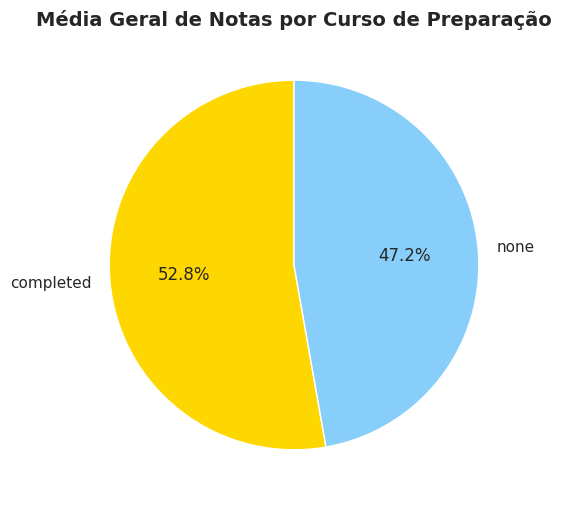

In [21]:
# Dados para o Desafio 2.5
df_prep_course = df_performance.groupby("test_preparation_course")[["math_score", "reading_score", "writing_score"]].mean().mean(axis=1).reset_index(name="overall_average_score")

plt.figure(figsize=(6, 6))
plt.pie(df_prep_course["overall_average_score"], labels=df_prep_course["test_preparation_course"], autopct="%1.1f%%", startangle=90, colors=["gold", "lightskyblue"])
plt.title("Média Geral de Notas por Curso de Preparação", fontsize=14, fontweight="bold")
plt.show()

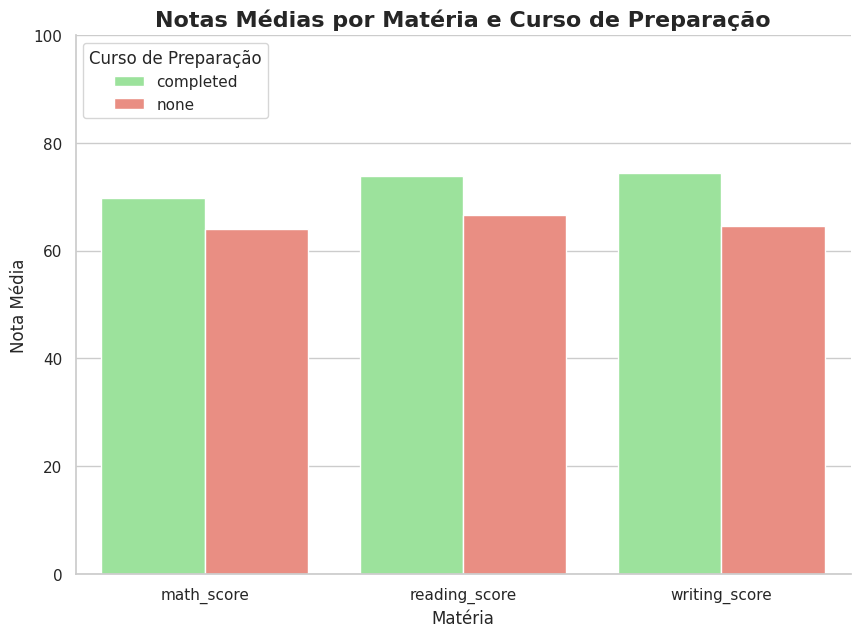

In [22]:
# 1. Problemas identificados:
#    a) Gráfico de Pizza para Comparar Média: Gráficos de pizza são muito ineficazes para comparar valores quantitativos, especialmente quando há mais de duas categorias. A percepção de área (fatias do pizza) é uma das codificações visuais menos precisas (Cleveland-McGill). É difícil comparar 50.8% com 49.2% de forma rápida e precisa sem ler os números, e seria ainda pior com mais categorias.
#    b) Média da Média (overall_average_score): Calcular a "média da média" das três matérias é estatisticamente problemático e pode esconder informações importantes. O desempenho geral pode ser melhor representado pelas médias individuais de cada matéria ou por um score composto mais robusto. Resumir tudo em uma única fatia de pizza ignora as nuances de desempenho em cada matéria (Tufte, Lie Factor por simplificação excessiva).
#    c) Múltiplas Variáveis Ineficazes: O gráfico tenta mostrar o impacto do curso de preparação no desempenho geral, mas esconde completamente o desempenho individual em matemática, leitura e escrita. O gráfico de pizza é unidimensional e não consegue representar eficazmente a comparação de desempenho em *múltiplas* matérias entre os grupos. Isso resulta em perda de informação crucial.

# 2. Seu código Python refatorado:
# Para comparar o desempenho médio em cada matéria entre os alunos que completaram e os que não completaram o curso de preparação, um gráfico de barras agrupadas é muito mais eficaz.

# Reestruturar os dados para ter as médias de cada matéria para cada grupo de curso de preparação
df_prep_course_detailed = df_performance.groupby("test_preparation_course")[["math_score", "reading_score", "writing_score"]].mean().reset_index()

# Derreter o dataframe para plotar as 3 matérias em um único gráfico de barras agrupadas
df_melted_prep = df_prep_course_detailed.melt(id_vars='test_preparation_course',
                                            var_name='Materia', value_name='Nota Media')

plt.figure(figsize=(10, 7))
sns.barplot(x='Materia', y='Nota Media', hue='test_preparation_course', data=df_melted_prep,
            palette={"none": "salmon", "completed": "lightgreen"})

plt.title("Notas Médias por Matéria e Curso de Preparação", fontsize=16, fontweight="bold")
plt.xlabel("Matéria")
plt.ylabel("Nota Média")
plt.ylim(0, 100) # As notas vão de 0 a 100
plt.legend(title="Curso de Preparação", loc='upper left')
sns.despine()
plt.show()